## 0. Imports & paths

In [5]:
import os
import json
import glob
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import defaultdict, Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image


BASE_DIR = Path(r"/Users/aning/Documents/BME1433-master")

DIR_24   = BASE_DIR / "24_chromosomes_object"
DIR_SNGL = BASE_DIR / "single_chromosomes_object"

ANN_24   = DIR_24 / "annotations"
IMG_24   = DIR_24 / "JEPG"        

ANN_SNGL = DIR_SNGL / "anntations" 
IMG_SNGL = DIR_SNGL / "JEPG"

TRAIN_TXT = BASE_DIR / "train.txt"
TEST_TXT  = BASE_DIR / "test.txt"
DIFF_TXT  = BASE_DIR / "diff_image.txt"

print("Base dir exists:", BASE_DIR.exists())

Base dir exists: True


## 1. Dataset Exploration

In [6]:
xml_24   = sorted(ANN_24.glob("*.xml"))
xml_sngl = sorted(ANN_SNGL.glob("*.xml"))
img_24   = sorted(IMG_24.glob("*.jpg")) + sorted(IMG_24.glob("*.JPG"))
img_sngl = sorted(IMG_SNGL.glob("*.jpg")) + sorted(IMG_SNGL.glob("*.JPG"))

print(f"24-chromosome dataset")
print(f"  XML annotations : {len(xml_24)}")
print(f"  Images          : {len(img_24)}")
print()
print(f"Single-chromosome dataset")
print(f"  XML annotations : {len(xml_sngl)}")
print(f"  Images          : {len(img_sngl)}")

24-chromosome dataset
  XML annotations : 5000
  Images          : 5000

Single-chromosome dataset
  XML annotations : 2000
  Images          : 2000


In [7]:
train_ids = TRAIN_TXT.read_text().splitlines()
test_ids  = TEST_TXT.read_text().splitlines()
diff_ids  = DIFF_TXT.read_text().splitlines()

print(f"Train samples     : {len(train_ids)}")
print(f"Test  samples     : {len(test_ids)}")
print(f"Difficult images  : {len(diff_ids)}")

Train samples     : 3750
Test  samples     : 1250
Difficult images  : 122


In [8]:
df_normal   = pd.read_csv(BASE_DIR / "normal.csv")
df_num_abn  = pd.read_csv(BASE_DIR / "number_abnormalities.csv")
df_str_abn  = pd.read_csv(BASE_DIR / "structural_abnormalities.csv")

print("Normal cases:", len(df_normal))
print("Number-abnormality cases:", len(df_num_abn))
print("Structural-abnormality cases:", len(df_str_abn))
display(df_normal.head(3))
display(df_num_abn.head(3))
display(df_str_abn.head(3))

Normal cases: 4893
Number-abnormality cases: 59
Structural-abnormality cases: 50


,filename,chromosome numbers,description
0,104011.jpg,46,NaN
1,104013.jpg,46,NaN
2,104022.jpg,46,NaN


,filename,chromosome numbers,description (abnormal chromosome-pair)
0,103081.jpg,47,unknow
1,103092.jpg,47,X
2,103131.jpg,47,12


,filename,chromosome numbers,description (abnormal chromosome-pair)
0,1050761.jpg,46,8
1,1050762.jpg,46,8
2,1050763.jpg,46,8


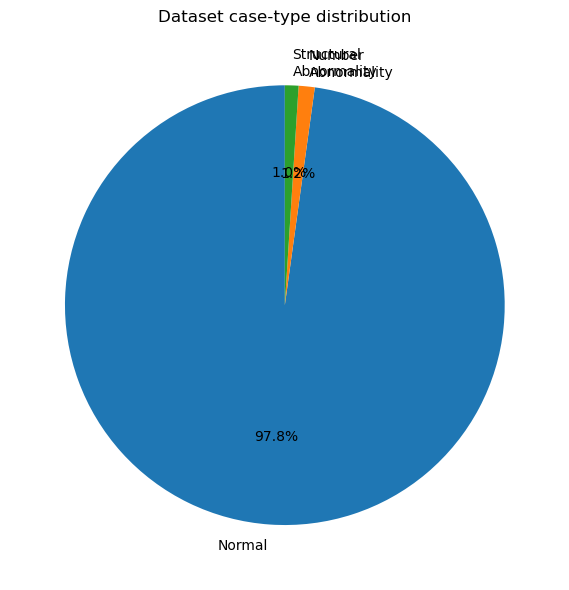

In [9]:
labels = ["Normal", "Number\nAbnormality", "Structural\nAbnormality"]
sizes  = [len(df_normal), len(df_num_abn), len(df_str_abn)]

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
ax.set_title("Dataset case-type distribution")
plt.tight_layout()
plt.show()

## 2. XML Helper Functions

In [10]:
def parse_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    size_node = root.find("size")
    width  = int(size_node.find("width").text)
    height = int(size_node.find("height").text)
    filename = root.find("filename").text

    objects = []
    for obj in root.findall("object"):
        name      = obj.find("name").text
        difficult = int(obj.find("difficult").text)
        bb = obj.find("bndbox")
        xmin = int(float(bb.find("xmin").text))
        ymin = int(float(bb.find("ymin").text))
        xmax = int(float(bb.find("xmax").text))
        ymax = int(float(bb.find("ymax").text))
        objects.append({
            "name": name,
            "difficult": difficult,
            "bbox_voc": [xmin, ymin, xmax, ymax],  
        })

    return {
        "filename": filename,
        "width": width,
        "height": height,
        "objects": objects,
    }


sample = parse_xml(xml_24[0])
print("Filename:", sample["filename"])
print("Size:", sample["width"], "x", sample["height"])
print("Objects:", len(sample["objects"]))
print("First object:", sample["objects"][0])

Filename: 103064.jpg
Size: 524 x 581
Objects: 46
First object: {'name': 'A1', 'difficult': 0, 'bbox_voc': [237, 274, 303, 393]}


In [11]:

CLASSES_24 = [
    "A1", "A2", "A3",
    "B4", "B5",
    "C6", "C7", "C8", "C9", "C10", "C11", "C12",
    "D13", "D14", "D15",
    "E16", "E17", "E18",
    "F19", "F20",
    "G21", "G22",
    "X", "Y",
]


CLASSES_SNGL = ["chromosomes"]


def xml_dir_to_coco(ann_dir, img_dir, classes, output_json_path,
                    split_ids=None, include_difficult=True):
    
    ann_dir = Path(ann_dir)
    output_json_path = Path(output_json_path)

    cat_name2id = {name: i + 1 for i, name in enumerate(classes)}

    coco = {
        "info": {
            "description": "Chromosome Karyotype Dataset",
            "version": "1.0",
        },
        "licenses": [],
        "categories": [
            {"id": i + 1, "name": name, "supercategory": "chromosome"}
            for i, name in enumerate(classes)
        ],
        "images": [],
        "annotations": [],
    }

    img_id  = 0
    ann_id  = 0
    skipped = 0
    unknown_classes = set()

    for xml_path in sorted(ann_dir.glob("*.xml")):
        stem = xml_path.stem
        if split_ids is not None and stem not in split_ids:
            continue

        data = parse_xml(xml_path)
        img_id += 1

        coco["images"].append({
            "id": img_id,
            "file_name": data["filename"],
            "width": data["width"],
            "height": data["height"],
        })

        for obj in data["objects"]:
            if not include_difficult and obj["difficult"]:
                continue

            cat_name = obj["name"]
            if cat_name not in cat_name2id:
                unknown_classes.add(cat_name)
                skipped += 1
                continue

            x1, y1, x2, y2 = obj["bbox_voc"]
            w = x2 - x1
            h = y2 - y1

            ann_id += 1
            coco["annotations"].append({
                "id": ann_id,
                "image_id": img_id,
                "category_id": cat_name2id[cat_name],
                "bbox": [x1, y1, w, h], 
                "area": w * h,
                "iscrowd": 0,
                "segmentation": [],
            })

    output_json_path.parent.mkdir(parents=True, exist_ok=True)
    with open(output_json_path, "w") as f:
        json.dump(coco, f, indent=2)

    if unknown_classes:
        print(f"  Warning: skipped {skipped} annotations with unknown classes: {unknown_classes}")
    print(f"  Saved  : {output_json_path}")
    print(f"  Images : {len(coco['images'])}")
    print(f"  Anns   : {len(coco['annotations'])}")



In [12]:
print("=== 24-chromosome dataset (full) ===")
xml_dir_to_coco(
    ann_dir=ANN_24,
    img_dir=IMG_24,
    classes=CLASSES_24,
    output_json_path=BASE_DIR / "coco_json" / "24_chromosomes_all.json",
)

=== 24-chromosome dataset (full) ===
  Saved  : /Users/aning/Documents/BME1433-master/coco_json/24_chromosomes_all.json
  Images : 5000
  Anns   : 229852


In [13]:
train_set = set(train_ids)
test_set  = set(test_ids)

print("=== 24-chromosome — train split ===")
xml_dir_to_coco(
    ann_dir=ANN_24,
    img_dir=IMG_24,
    classes=CLASSES_24,
    output_json_path=BASE_DIR / "coco_json" / "24_chromosomes_train.json",
    split_ids=train_set,
)

print()
print("=== 24-chromosome — test split ===")
xml_dir_to_coco(
    ann_dir=ANN_24,
    img_dir=IMG_24,
    classes=CLASSES_24,
    output_json_path=BASE_DIR / "coco_json" / "24_chromosomes_test.json",
    split_ids=test_set,
)

=== 24-chromosome — train split ===
  Saved  : /Users/aning/Documents/BME1433-master/coco_json/24_chromosomes_train.json
  Images : 3744
  Anns   : 172095

=== 24-chromosome — test split ===
  Saved  : /Users/aning/Documents/BME1433-master/coco_json/24_chromosomes_test.json
  Images : 1250
  Anns   : 57484


In [14]:
print("=== Single-chromosome dataset (full) ===")
xml_dir_to_coco(
    ann_dir=ANN_SNGL,
    img_dir=IMG_SNGL,
    classes=CLASSES_SNGL,
    output_json_path=BASE_DIR / "coco_json" / "single_chromosomes_all.json",
)

=== Single-chromosome dataset (full) ===
  Saved  : /Users/aning/Documents/BME1433-master/coco_json/single_chromosomes_all.json
  Images : 2000
  Anns   : 92308


## 4. Visualization — Images with Bounding Boxes

In [15]:
GROUP_COLORS = {
    "A": "#e6194b", "B": "#3cb44b", "C": "#4363d8",
    "D": "#f58231", "E": "#911eb4", "F": "#42d4f4",
    "G": "#f032e6", "X": "#bfef45", "Y": "#fabed4",
}

def class_color(cls_name):
    group = cls_name[0].upper() if cls_name[0].upper() in GROUP_COLORS else "X"
    return GROUP_COLORS.get(group, "white")


def visualise_annotation(xml_path, img_dir, ax=None):
    """Draw an image with its bounding boxes."""
    data = parse_xml(xml_path)
    stem = Path(xml_path).stem


    img_path = None
    for ext in (".jpg", ".JPG", ".jpeg", ".JPEG", ".png"):
        candidate = Path(img_dir) / (stem + ext)
        if candidate.exists():
            img_path = candidate
            break

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 8))

    if img_path is not None:
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
    else:
        ax.set_xlim(0, data["width"])
        ax.set_ylim(data["height"], 0)
        ax.set_facecolor("#cccccc")
        ax.text(data["width"] / 2, data["height"] / 2,
                "image not found", ha="center", va="center", fontsize=10)

    for obj in data["objects"]:
        x1, y1, x2, y2 = obj["bbox_voc"]
        color = class_color(obj["name"])
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=1.5, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 2, obj["name"],
                color=color, fontsize=6, fontweight="bold",
                bbox=dict(facecolor="black", alpha=0.4, pad=1, linewidth=0))

    ax.set_title(stem, fontsize=9)
    ax.axis("off")


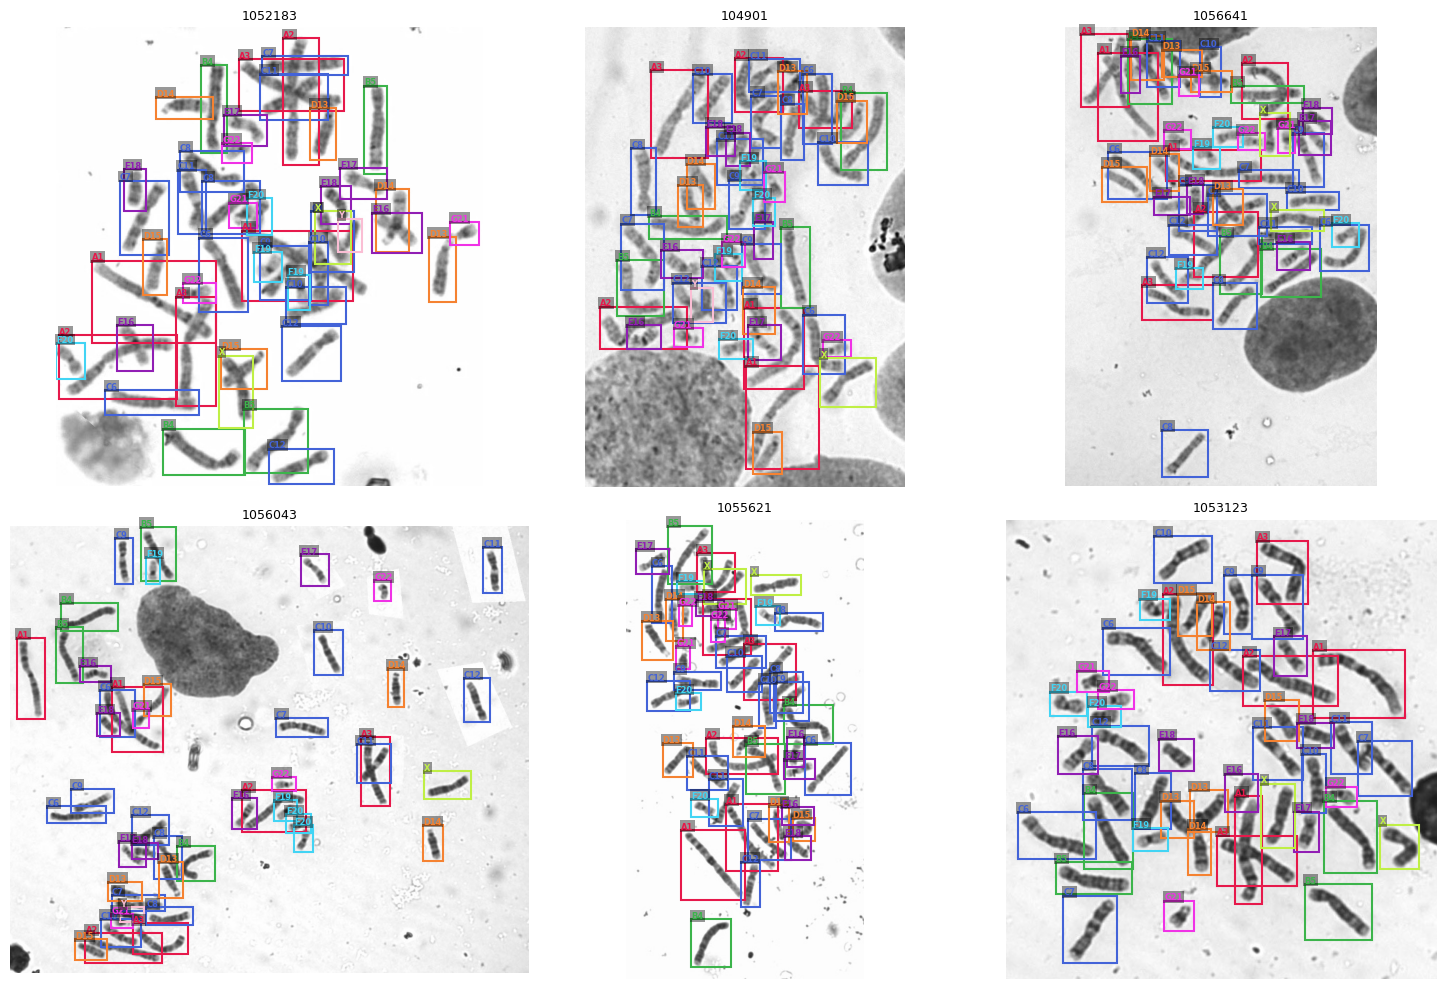

In [16]:
import random
random.seed(42)
samples = random.sample(xml_24, min(6, len(xml_24)))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, xml_path in zip(axes.flatten(), samples):
    visualise_annotation(xml_path, IMG_24, ax=ax)

plt.tight_layout()
plt.show()

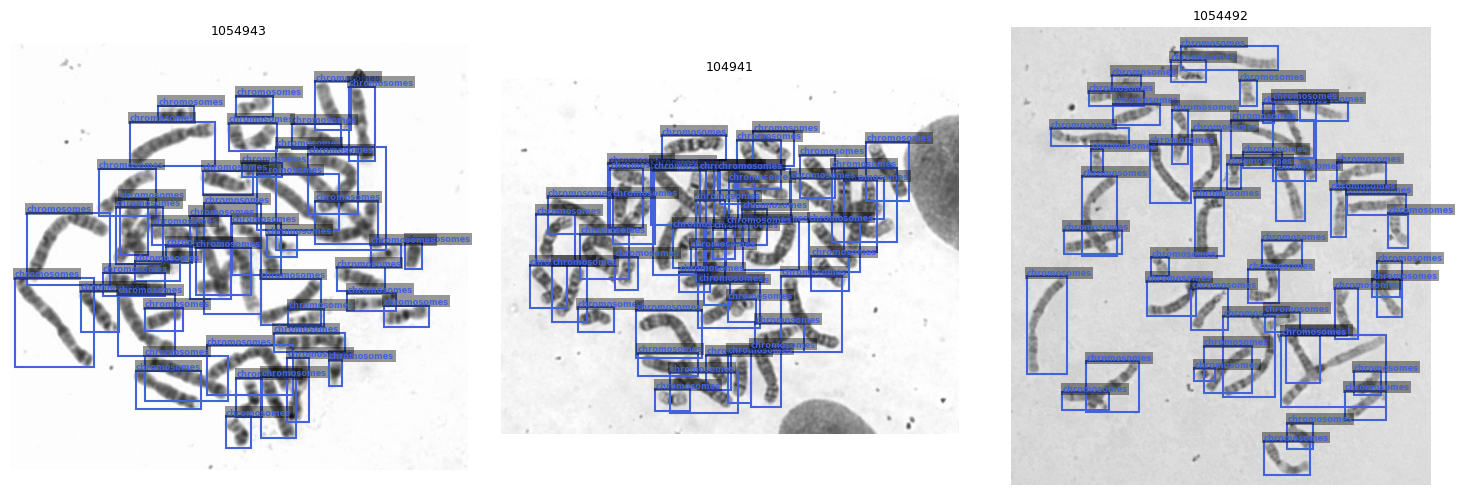

In [17]:
samples_sngl = random.sample(xml_sngl, min(3, len(xml_sngl)))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, xml_path in zip(axes.flatten(), samples_sngl):
    visualise_annotation(xml_path, IMG_SNGL, ax=ax)


plt.tight_layout()
plt.show()

## 5. Class Distribution Analysis

In [18]:
def count_classes(xml_files):
    counter = Counter()
    for xp in xml_files:
        data = parse_xml(xp)
        for obj in data["objects"]:
            counter[obj["name"]] += 1
    return counter

counts_24 = count_classes(xml_24)


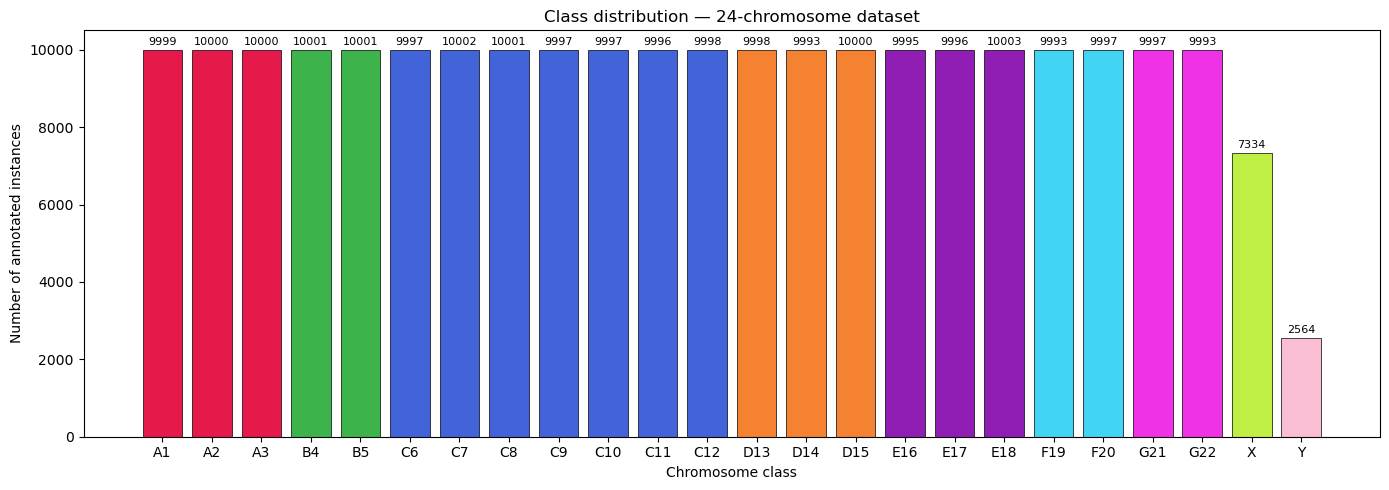


Total annotations: 229852
Total images     : 5000
Avg anns/image   : 46.0


In [19]:

ordered = [(cls, counts_24.get(cls, 0)) for cls in CLASSES_24]
names, counts = zip(*ordered)

colors = [class_color(n) for n in names]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(names, counts, color=colors, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Chromosome class")
ax.set_ylabel("Number of annotated instances")
ax.set_title("Class distribution — 24-chromosome dataset")
ax.bar_label(bars, padding=2, fontsize=8)
plt.tight_layout()
plt.show()

print(f"\nTotal annotations: {sum(counts)}")
print(f"Total images     : {len(xml_24)}")
print(f"Avg anns/image   : {sum(counts)/len(xml_24):.1f}")

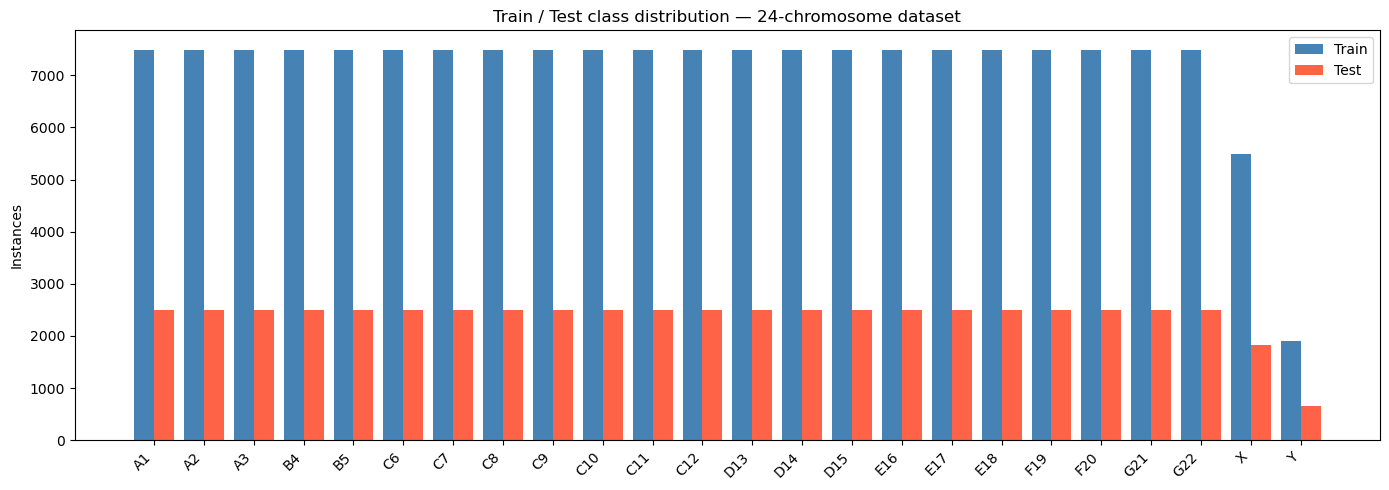

,class,train,test
0,A1,7488,2499
1,A2,7488,2500
2,A3,7488,2500
3,B4,7488,2501
4,B5,7489,2500
5,C6,7486,2500
6,C7,7489,2501
7,C8,7489,2500
8,C9,7487,2499
9,C10,7486,2499


In [20]:
train_xml = [x for x in xml_24 if x.stem in train_set]
test_xml  = [x for x in xml_24 if x.stem in test_set]

counts_train = count_classes(train_xml)
counts_test  = count_classes(test_xml)

df_dist = pd.DataFrame({
    "class":  CLASSES_24,
    "train":  [counts_train.get(c, 0) for c in CLASSES_24],
    "test":   [counts_test.get(c,  0) for c in CLASSES_24],
})

x = np.arange(len(CLASSES_24))
width = 0.4

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, df_dist["train"], width, label="Train", color="steelblue")
ax.bar(x + width/2, df_dist["test"],  width, label="Test",  color="tomato")
ax.set_xticks(x)
ax.set_xticklabels(CLASSES_24, rotation=45, ha="right")
ax.set_ylabel("Instances")
ax.set_title("Train / Test class distribution — 24-chromosome dataset")
ax.legend()
plt.tight_layout()
plt.show()

display(df_dist)

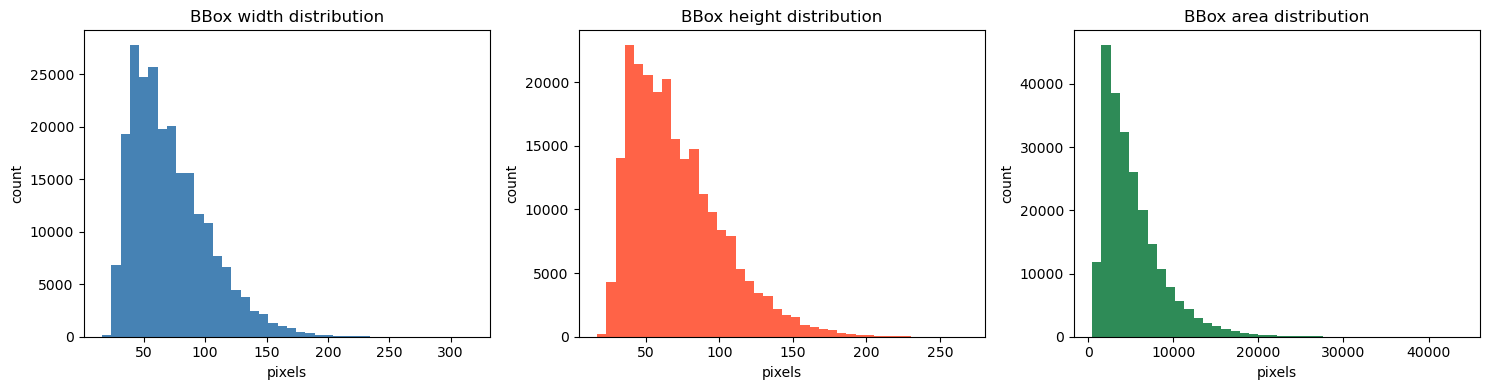

Width  — mean: 71.6  std: 31.2
Height — mean: 71.2  std: 31.2
Area   — mean: 5238  std: 3595


In [21]:
widths, heights, areas = [], [], []
for xp in xml_24:
    data = parse_xml(xp)
    for obj in data["objects"]:
        x1, y1, x2, y2 = obj["bbox_voc"]
        w, h = x2 - x1, y2 - y1
        widths.append(w)
        heights.append(h)
        areas.append(w * h)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(widths,  bins=40, color="steelblue")
axes[0].set_title("BBox width distribution")
axes[1].hist(heights, bins=40, color="tomato")
axes[1].set_title("BBox height distribution")
axes[2].hist(areas,   bins=40, color="seagreen")
axes[2].set_title("BBox area distribution")
for ax in axes:
    ax.set_xlabel("pixels")
    ax.set_ylabel("count")
plt.tight_layout()
plt.show()

print(f"Width  — mean: {np.mean(widths):.1f}  std: {np.std(widths):.1f}")
print(f"Height — mean: {np.mean(heights):.1f}  std: {np.std(heights):.1f}")
print(f"Area   — mean: {np.mean(areas):.0f}  std: {np.std(areas):.0f}")

In [22]:
def xml_to_yolo(xml_path, classes, output_dir, include_difficult=True):

    data = parse_xml(xml_path)
    W, H = data["width"], data["height"]
    class2id = {c: i for i, c in enumerate(classes)}

    lines = []
    for obj in data["objects"]:
        if not include_difficult and obj["difficult"]:
            continue
        if obj["name"] not in class2id:
            continue
        x1, y1, x2, y2 = obj["bbox_voc"]
        cx = ((x1 + x2) / 2) / W
        cy = ((y1 + y2) / 2) / H
        bw = (x2 - x1) / W
        bh = (y2 - y1) / H
        cls_id = class2id[obj["name"]]
        lines.append(f"{cls_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")

    out_path = Path(output_dir) / (Path(xml_path).stem + ".txt")
    out_path.parent.mkdir(parents=True, exist_ok=True)
    out_path.write_text("\n".join(lines))
    return out_path


def convert_all_to_yolo(ann_dir, classes, output_dir, split_ids=None):
    ann_dir    = Path(ann_dir)
    output_dir = Path(output_dir)
    converted  = 0
    for xml_path in sorted(ann_dir.glob("*.xml")):
        if split_ids is not None and xml_path.stem not in split_ids:
            continue
        xml_to_yolo(xml_path, classes, output_dir)
        converted += 1
    print(f"  Converted {converted} files → {output_dir}")

print("YOLO conversion functions defined.")

YOLO conversion functions defined.


In [23]:
YOLO_24_DIR = BASE_DIR / "yolo_labels" / "24_chromosomes"

convert_all_to_yolo(ANN_24, CLASSES_24, YOLO_24_DIR)


sample_txt = list(YOLO_24_DIR.glob("*.txt"))[0]
print(f"\nSample label file: {sample_txt.name}")
print(sample_txt.read_text()[:300])

  Converted 5000 files → /Users/aning/Documents/BME1433-master/yolo_labels/24_chromosomes

Sample label file: 1100564.txt
0 0.116168 0.856335 0.096467 0.171946
0 0.255435 0.483597 0.084239 0.123303
1 0.386549 0.259050 0.145380 0.115385
1 0.143342 0.377828 0.118207 0.151584
2 0.372962 0.618213 0.093750 0.125566
2 0.140625 0.533937 0.074728 0.138009
3 0.663043 0.321833 0.152174 0.041855
3 0.661685 0.300339 0.086957 0.116


In [24]:
YOLO_SNGL_DIR = BASE_DIR / "yolo_labels" / "single_chromosomes"

convert_all_to_yolo(ANN_SNGL, CLASSES_SNGL, YOLO_SNGL_DIR)

  Converted 2000 files → /Users/aning/Documents/BME1433-master/yolo_labels/single_chromosomes


In [25]:

(YOLO_24_DIR / "classes.txt").write_text("\n".join(CLASSES_24))
print("Written:", YOLO_24_DIR / "classes.txt")

(YOLO_SNGL_DIR / "classes.txt").write_text("\n".join(CLASSES_SNGL))
print("Written:", YOLO_SNGL_DIR / "classes.txt")

Written: /Users/aning/Documents/BME1433-master/yolo_labels/24_chromosomes/classes.txt
Written: /Users/aning/Documents/BME1433-master/yolo_labels/single_chromosomes/classes.txt


## 7. Generate YOLOv4 Image List Files

YOLOv4 needs absolute paths to images in its train/test `.txt` files.

In [26]:
def write_yolo_image_list(ids, img_dir, output_path, ext=".jpg"):

    lines = []
    missing = 0
    for stem in ids:
        found = False
        for e in (".jpg", ".JPG", ".jpeg", ".JPEG", ".png"):
            p = Path(img_dir) / (stem + e)
            if p.exists():
                lines.append(str(p.resolve()))
                found = True
                break
        if not found:
            missing += 1

    Path(output_path).write_text("\n".join(lines))
    print(f"  Written {len(lines)} paths ({missing} missing) → {output_path}")


write_yolo_image_list(train_ids, IMG_24, BASE_DIR / "yolo_train_24.txt")
write_yolo_image_list(test_ids,  IMG_24, BASE_DIR / "yolo_test_24.txt")

  Written 3744 paths (6 missing) → /Users/aning/Documents/BME1433-master/yolo_train_24.txt
  Written 1250 paths (0 missing) → /Users/aning/Documents/BME1433-master/yolo_test_24.txt


## 8. Summary

In [27]:
with open(BASE_DIR / "coco_json" / "24_chromosomes_all.json") as f:
    coco_full = json.load(f)

print("=" * 55)
print("DATASET SUMMARY")
print("=" * 55)
print(f"24-chromosome images          : {len(xml_24)}")
print(f"  Train / Test                : {len(train_xml)} / {len(test_xml)}")
print(f"  Difficult images            : {len(diff_ids)}")
print(f"  Total annotations (COCO)    : {len(coco_full['annotations'])}")
print(f"  Unique classes              : {len(CLASSES_24)}")
print()
print(f"Single-chromosome images      : {len(xml_sngl)}")
print()
print("Outputs written:")
print(f"  coco_json/24_chromosomes_all.json")
print(f"  coco_json/24_chromosomes_train.json")
print(f"  coco_json/24_chromosomes_test.json")
print(f"  coco_json/single_chromosomes_all.json")
print(f"  yolo_labels/24_chromosomes/ (*.txt + classes.txt)")
print(f"  yolo_labels/single_chromosomes/ (*.txt + classes.txt)")
print(f"  yolo_train_24.txt / yolo_test_24.txt")

DATASET SUMMARY
24-chromosome images          : 5000
  Train / Test                : 3744 / 1250
  Difficult images            : 122
  Total annotations (COCO)    : 229852
  Unique classes              : 24

Single-chromosome images      : 2000

Outputs written:
  coco_json/24_chromosomes_all.json
  coco_json/24_chromosomes_train.json
  coco_json/24_chromosomes_test.json
  coco_json/single_chromosomes_all.json
  yolo_labels/24_chromosomes/ (*.txt + classes.txt)
  yolo_labels/single_chromosomes/ (*.txt + classes.txt)
  yolo_train_24.txt / yolo_test_24.txt


## 9. Denver Group Analysis from Ground Truth Labels

Total annotated chromosomes: 229852
Images: 5000

Denver group proportions (observed vs expected):


,observed_%,expected_%
A,13.1,13.0
B,8.7,8.7
C,30.4,34.8
D,13.0,13.0
E,13.0,13.0
F,8.7,8.7
G,13.0,8.7


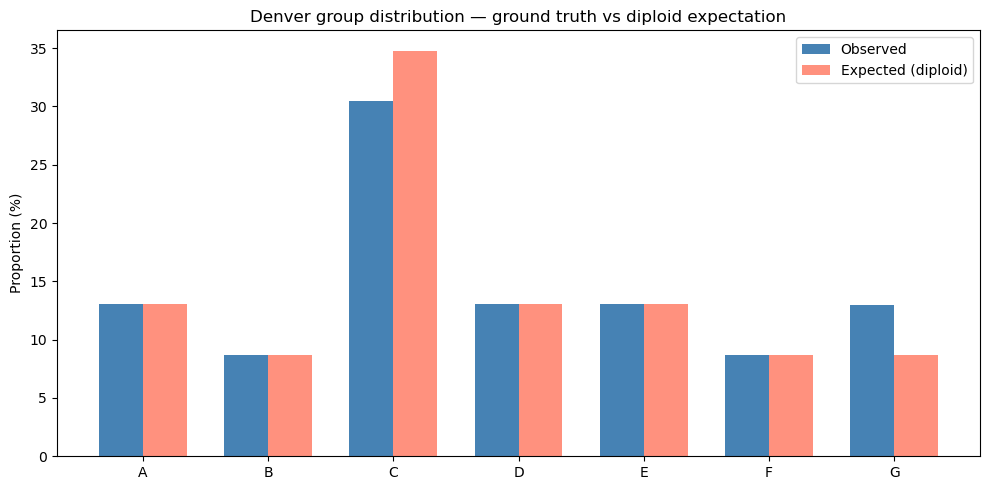


Per-image group counts (first 5 images):


denver_group,A,B,C,D,E,F,G
filename,,,,,,,
103064.jpg,6,4,14,6,6,4,6
103071.jpg,6,4,14,6,6,4,6
103072.jpg,6,4,14,6,6,4,6
103081.jpg,6,4,14,6,6,4,7
103082.jpg,6,4,14,6,6,4,6



Mean counts per image:


,mean_count
denver_group,
A,6.00
B,4.00
C,14.00
D,6.00
E,6.00
F,4.00
G,5.98


In [28]:

# Denver group is encoded in the first letter of each class label (A1→A, B4→B, etc.)
# X and Y are grouped into G per Denver convention (very small acrocentrics)
def label_to_denver_group(name):
    if name in ('X', 'Y'):
        return 'G'
    return name[0]

# Build flat DataFrame of all annotations with Denver group
records = []
for xml_path in xml_24:
    data = parse_xml(xml_path)
    for obj in data['objects']:
        records.append({
            'filename':     data['filename'],
            'label':        obj['name'],
            'denver_group': label_to_denver_group(obj['name']),
        })

df_denver = pd.DataFrame(records)
print(f"Total annotated chromosomes: {len(df_denver)}")
print(f"Images: {df_denver['filename'].nunique()}")

# ── Expected counts per group (diploid: 46 chromosomes) ──────────────────────
EXPECTED = {'A': 6, 'B': 4, 'C': 16, 'D': 6, 'E': 6, 'F': 4, 'G': 4}

# Overall proportion across all images
proportions = df_denver['denver_group'].value_counts(normalize=True).sort_index() * 100
expected_pct = pd.Series(EXPECTED) / 46 * 100

df_prop = pd.DataFrame({
    'observed_%': proportions.round(1),
    'expected_%': expected_pct.round(1),
})
print("\nDenver group proportions (observed vs expected):")
display(df_prop)

# ── Bar chart: observed vs expected ──────────────────────────────────────────
groups = sorted(EXPECTED.keys())
x = np.arange(len(groups))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, [proportions.get(g, 0) for g in groups], width,
       label='Observed', color='steelblue')
ax.bar(x + width/2, [expected_pct.get(g, 0) for g in groups], width,
       label='Expected (diploid)', color='tomato', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylabel('Proportion (%)')
ax.set_title('Denver group distribution — ground truth vs diploid expectation')
ax.legend()
plt.tight_layout()
plt.show()

# ── Per-image group counts (useful for validating classify_denver_groups) ─────
group_counts = (df_denver
                .groupby(['filename', 'denver_group'])
                .size()
                .unstack(fill_value=0)
                .reindex(columns=groups, fill_value=0))

print("\nPer-image group counts (first 5 images):")
display(group_counts.head())
print(f"\nMean counts per image:")
display(group_counts.mean().round(2).to_frame('mean_count'))
